# Flight Data Processing

## To do
1. Input and process GPS data
3. Plot everything on a massive grid

In [1]:
# Install dependencies
%pip install pynmea2 numpy matplotlib scienceplots

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Setup nice scientific styling

import matplotlib.pyplot as plt
import scienceplots

# nice scientific styling
plt.style.use("science")
# match report font size
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
# match report font
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]
})

In [3]:
import numpy as np
import pynmea2
import datetime
from typing import Union

def latlon_to_northeast(lat0, lon0, lat, lon):
    """convert lat, lon [degrees] to east (y+), north (x+) [m] with origin lat0, lon0 [degrees]
    """
    R = 6378137.0  # Earth radius [m]

    lat1_rad = np.radians(lat0)
    lat2_rad = np.radians(lat)

    dlat = np.radians(lat - lat0)
    dlon = np.radians(lon - lon0)

    north_m = dlat * R
    east_m = dlon * R * np.cos((lat1_rad + lat2_rad) / 2)

    return east_m, north_m

def rotation_matrix_from_vectors(a, b):
    """Calculates the rotation vector for R @ a = b"""

    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)

    v = np.cross(a, b)
    c = np.dot(a, b)
    s = np.linalg.norm(v)

    kmat = np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

    R = np.eye(3) + kmat + kmat @ kmat * ((1 - c) / (s**2))
    return R

def none_to_nan(arr: np.ndarray) -> np.ndarray:
    return np.array(
        [np.nan if x is None else x for x in arr],
        dtype=float
    )

class GPS:
    def __init__(self, filepath: str, recording_num: int = 0, gps_lag_ms: float = 0) -> None:
        # read rows
        rows = []
        next_row: list[Union[float, list[str]]] = []
        with open(filepath) as f:
            for line in f:
                line = line.strip()
                # handle header lines
                if not line or not (line[0].isnumeric() or line[0] == "$"):
                    continue
                if line[0].isnumeric() and not line.split(",")[1].startswith("$"):
                    continue
                if line[0].isnumeric():
                    # add the last compute row to the rows
                    if next_row:
                        rows.append(next_row)
                    next_row = [
                        float(line.split(",")[0]),
                        [",".join(line.split(",")[1:])]
                    ]
                if line[0] == "$":
                    next_row[1].append(line) # type: ignore

        # extract data from NMEA Sentences
        time = None # type: ignore
        date = None
        lat = None
        lon = None
        alt = None
        num_sats = None
        ground_speed_knots = None
        fix_type = None
        pdop = None
        hdop = None
        vdop = None
        last_timestamp = 0
        datapoints = []

        for row in rows:
            timestamp = row[0]
            if timestamp != last_timestamp:
                # save data
                if any([time, date, lat, lon, alt, num_sats, ground_speed_knots, fix_type, pdop, hdop, vdop]):
                    datapoints.append([timestamp, time, date, lat, lon, alt, num_sats, ground_speed_knots, fix_type, pdop, hdop, vdop])

                # reset variables
                time = None # type: ignore
                date = None
                lat = None
                lon = None
                alt = None
                num_sats = None
                ground_speed_knots = None
                fix_type = None
                pdop = None
                hdop = None
                vdop = None
                pass
            last_timestamp = timestamp

            nmea_sentences = row[1]
            for sentence in nmea_sentences:
                
                try:
                    # decode msg
                    msg = pynmea2.parse(sentence)

                    # GGA: detailed fix
                    if isinstance(msg, pynmea2.types.talker.GGA):
                        time: datetime.time = msg.timestamp # type: ignore
                        lat = msg.latitude # signed degrees
                        lon = msg.longitude # signed degrees
                        alt = msg.altitude # m
                        num_sats = msg.num_sats
                        # print(f"[GGA] Time: {msg.timestamp} | Lat: {msg.latitude} {msg.lat_dir} | Lon: {msg.longitude} {msg.lon_dir} | Alt: {msg.altitude} {msg.altitude_units} | Satellites: {msg.num_sats} | Fix Quality: {msg.gps_qual}")

                    # RMC: recommended minimum
                    elif isinstance(msg, pynmea2.types.talker.RMC):
                        if msg.status != "A":
                            continue
                        time: datetime.time = msg.timestamp # type: ignore
                        date = msg.datestamp
                        if not isinstance(date, datetime.date):
                            date = None
                        lat = msg.latitude # signed degrees
                        lon = msg.longitude # signed degrees
                        ground_speed_knots = msg.spd_over_grnd
                        # print(f"[RMC] Time: {msg.timestamp} | Status: {msg.status} | Lat: {msg.latitude} {msg.lat_dir} | Lon: {msg.longitude} {msg.lon_dir} | Speed (knots): {msg.spd_over_grnd} | Date: {msg.datestamp}")

                    # GSA: DOP and satellites used
                    elif isinstance(msg, pynmea2.types.talker.GSA):
                        fix_type = msg.mode_fix_type
                        pdop = msg.pdop # overall accuracy
                        hdop = msg.hdop # horizontal accuracy
                        vdop = msg.vdop # vertical accuracy
                        # print(f"[GSA] Mode: {msg.mode} | Fix Type: {msg.mode_fix_type} | PDOP: {msg.pdop} | HDOP: {msg.hdop} | VDOP: {msg.vdop}")

                    # GSV: satellites in view
                    elif isinstance(msg, pynmea2.types.talker.GSV):
                        pass
                        # print(f"[GSV] Total Messages: {msg.num_messages} | Message Number: {msg.msg_num} | Satellites in View: {msg.num_sv_in_view}")

                    # GLL: latitude/longitude
                    elif isinstance(msg, pynmea2.types.talker.GLL):
                        if msg.status != "A":
                            continue
                        time: datetime.time = msg.timestamp # type: ignore
                        lat = msg.latitude # signed degrees
                        lon = msg.longitude # signed degrees
                        # print(f"[GLL] Lat: {msg.latitude} {msg.lat_dir} | Lon: {msg.longitude} {msg.lon_dir} | Time: {msg.timestamp} | Status: {msg.status}")

                except (pynmea2.ParseError, ValueError) as e:
                    # print("Failed to parse:", e)
                    pass

        # save datapoints to np array
        data = np.array(datapoints)

        # trim data to exclude data recorded from other flights
        if recording_num:
            idx = np.concatenate((
                [0],
                np.where(np.diff(data[:, 0]) < 0)[0] + 1,
                [len(data) + 1]
            ))

            if recording_num < 1 or recording_num > len(idx) - 1:
                raise ValueError(f"invalid recording_num: only {len(idx)-1} recordings are present within this csv file and recording {recording_num} was requested.")
            lower_idx = idx[recording_num-1]
            upper_idx = idx[recording_num]
            data = data[lower_idx: upper_idx]        

        # save data
        self.data = data

        # breakout into different parameters
        self.timestamp_ms = data[:, 0] - gps_lag_ms
        self.time = data[: , 1]
        self.date = data[: , 2]
        self.lat = none_to_nan(data[: , 3])
        self.lon = none_to_nan(data[: , 4])
        self.elevation = none_to_nan(data[: , 5])
        self.num_sats = data[: , 6]
        self.ground_speed_knots = data[: , 7]
        self.fix_type = data[: , 8]
        self.pdop = data[: , 9]
        self.hdop = data[: , 10]
        self.vdop = data[: , 11]

        self.alt = self.elevation - self.ground_altitude

    @property
    def ground_altitude(self):
        return np.nanpercentile(self.elevation, 5)

    def get_local_xy(self, lat0, lon0) -> tuple[np.ndarray, np.ndarray]:
        """get the local x and y coordinates from the GPS latitude and longitude using the provided reference as the origin (0, 0).count

        Uses the great circle approximation. Assumes a spherical Earth.

        All angles are in degrees.        

        Args:
            lat0: latitude reference
            lon0: longitude reference

        Returns:
            tuple of np arrays (x, y)
        """

        return latlon_to_northeast(lat=self.lat, lon=self.lon, lat0=lat0, lon0=lon0)
    

    def __repr__(self) -> str:
        return f"<GPS n={len(self.data)}>"

class CSV_File:
    def __init__(self, filepath: str, name: str, recording_num: int = 0) -> None:
        self.name = name
        self.data = self.read_csv(filepath, recording_num)

    def read_csv(self, filepath: str, recording_num: int = 0) -> np.ndarray:
        # read csv data
        rows = []
        with open(filepath) as f:
            for line in f:
                line = line.strip()
                # handle header lines
                if not line or not line[0].isnumeric():
                    continue
                rows.append([float(x) for x in line.split(",")])
        data = np.array(rows)

        # trim data to exclude data recorded from other flights
        if recording_num:
            idx = np.concatenate((
                [0],
                np.where(np.diff(data[:, 0]) < 0)[0] + 1,
                [len(data) + 1]
            ))
            if recording_num < 1 or recording_num > len(idx) - 1:
                raise ValueError(f"invalid recording_num: only {len(idx)-1} recordings are present within this csv file and recording {recording_num} was requested.")
            lower_idx = idx[recording_num-1]
            upper_idx = idx[recording_num]
            data = data[lower_idx: upper_idx]
        
        return data

    def __repr__(self) -> str:
        return f"<{self.name} n={len(self.data)}>"

class Barometer(CSV_File):
    def __init__(self, filepath: str, recording_num: int = 0) -> None:
        super().__init__(filepath, "Barometer", recording_num)
        self.timestamp_ms = self.data[:, 0]
        self.temp_c = self.data[:, 1]
        self.pressure_pa = self.data[:, 2]
        self.elevation_m = self.data[:, 3]

        self.alt_m = self.elevation_m - np.percentile(self.elevation_m, 5)


class IMU(CSV_File):
    def __init__(self, filepath: str, recording_num: int = 0) -> None:
        super().__init__(filepath, "IMU", recording_num)
        self.timestamp_ms = self.data[:, 0]
        self.heading = self.data[:, 1]
        self.roll = self.data[:, 2]
        self.pitch = self.data[:, 3]
        self.qw = self.data[:, 4]
        self.qx = self.data[:, 5]
        self.qy = self.data[:, 6]
        self.qz = self.data[:, 7]
        self.gx = self.data[:, 8]
        self.gy = self.data[:, 9]
        self.gz = self.data[:, 10]
        self.ax = self.data[:, 11]
        self.ay = self.data[:, 12]
        self.az = self.data[:, 13]
        self.lin_x = self.data[:, 14]
        self.lin_y = self.data[:, 15]
        self.lin_z = self.data[:, 16]
        self.grav_x = self.data[:, 17]
        self.grav_y = self.data[:, 18]
        self.grav_z = self.data[:, 19]
        self.mag_x = self.data[:, 20]
        self.mag_y = self.data[:, 21]
        self.mag_z = self.data[:, 22]
        self.temp_c = self.data[:, 23]

    @property
    def a(self) -> np.ndarray:
        return np.column_stack([self.ax, self.ay, self.az])
    
    @property
    def g(self) -> np.ndarray:
        return np.column_stack([self.gx, self.gy, self.gz])

    @property
    def lin_a(self) -> np.ndarray:
        return np.column_stack([self.lin_x, self.lin_y, self.lin_z])
    
    

    def detect_launch(self, threshold_acceleration: float = 3, required_consecutive: int = 5) -> float:
        """detect launch time and return timestamp in ms. returns the first instance

        Args:
            threshold_acceleration: minimum acceleration threshold [m/s^2]. Defaults to 4.
            required_consecutive: minimum consecutive datapoints that meet this threshold. Defaults to 5.

        Returns:
            launch timestamp [ms]
        """
        vertical_acceleration = self.lin_y
        timestamps = self.timestamp_ms

        mask = (vertical_acceleration > threshold_acceleration)

        count = 0
        for i, passed in enumerate(mask):
            if passed:
                count += 1
            else:
                count = 0
            
            if count >= required_consecutive:
                return timestamps[i - required_consecutive + 1]
        
        return None # type: ignore

bar = Barometer("./data/barometer.csv", 2)
imu = IMU("./data/imu.csv", 2)
gps = GPS("./data/gps.txt", 1, 1000)

print(bar)
print(imu)
print(gps)

<Barometer n=2925>
<IMU n=2926>
<GPS n=1075>


In [4]:
print(f"Ground altitude: {gps.ground_altitude} m")

Ground altitude: 90.3 m


In [5]:
# Verify the barometer and imu have the same timestamp

for i in range(len(bar.timestamp_ms)):
    if bar.timestamp_ms[i] != imu.timestamp_ms[i]:
        print(f"bar: {bar.timestamp_ms[i]}, imu: {imu.timestamp_ms[i]}")

In [6]:
# Extended Kalman Filter
# from enum import IntEnum

# q = np.column_stack([imu.qx, imu.qy, imu.qz, imu.qw])
# bar_elevation = bar.elevation_m

# x, y = gps.get_local_xy(gps.lat[0], gps.lon[0])
# z = gps.elevation
# gps_pos = np.column_stack([x, y, z])

# class Sensor(IntEnum):
#     Barometer = 1
#     IMU = 2
#     GPS = 3


# class FlightSimulator:
#     def __init__(self, bar: Barometer, imu: IMU, gps: GPS) -> None:
#         """[(Sensor, Index, Timestamp [ms]), ...]"""
#         events: list[tuple[Sensor, int, int]] = [
#             *[(Sensor.Barometer, i, t) for i, t in enumerate(bar.timestamp_ms)],
#             *[(Sensor.IMU, i, t) for i, t in enumerate(imu.timestamp_ms)],
#             *[(Sensor.GPS, i, t) for i, t in enumerate(gps.timestamp_ms)]
#         ]
#         self.events = sorted(events, key=lambda item: item[2])

#     def __iter__(self):
#         return iter(self.events)

# for sensor, index, ts in FlightSimulator(bar, imu, gps):
#     match sensor:
#         case Sensor.IMU:
#             qx, qy, qz, qw = q[index]
#         case Sensor.GPS:
#             x, y, z = gps_pos[index]
#         case Sensor.Barometer:
#             z = bar_elevation[index]

In [7]:
# relate timestamp to real GPS time (UTC)
# this assumes the microcontroller internal timing system runs at utc time

for i in range(len(gps.data)):
    if gps.date[i] and gps.time[i]:
        gps_dt = datetime.datetime.combine(gps.date[i], gps.time[i])
        microcontroller_timestamp_ms = gps.timestamp_ms[i]
        TIME_OFFSET_MS = gps_dt.timestamp() * 1000 - microcontroller_timestamp_ms
        break

def timestamp_ms_to_datetime(timestamp_ms: int) -> datetime.datetime:
    return datetime.datetime.fromtimestamp((TIME_OFFSET_MS + timestamp_ms) / 1000, datetime.timezone.utc)

# testing
for ts in bar.timestamp_ms[:10]:
    print(f"{ts} ms = {timestamp_ms_to_datetime(ts)}")

1017.0 ms = 2025-11-09 13:40:27.177000+00:00
1114.0 ms = 2025-11-09 13:40:27.274000+00:00
1367.0 ms = 2025-11-09 13:40:27.527000+00:00
2559.0 ms = 2025-11-09 13:40:28.719000+00:00
2696.0 ms = 2025-11-09 13:40:28.856000+00:00
2840.0 ms = 2025-11-09 13:40:29+00:00
3570.0 ms = 2025-11-09 13:40:29.730000+00:00
3714.0 ms = 2025-11-09 13:40:29.874000+00:00
4564.0 ms = 2025-11-09 13:40:30.724000+00:00
4709.0 ms = 2025-11-09 13:40:30.869000+00:00


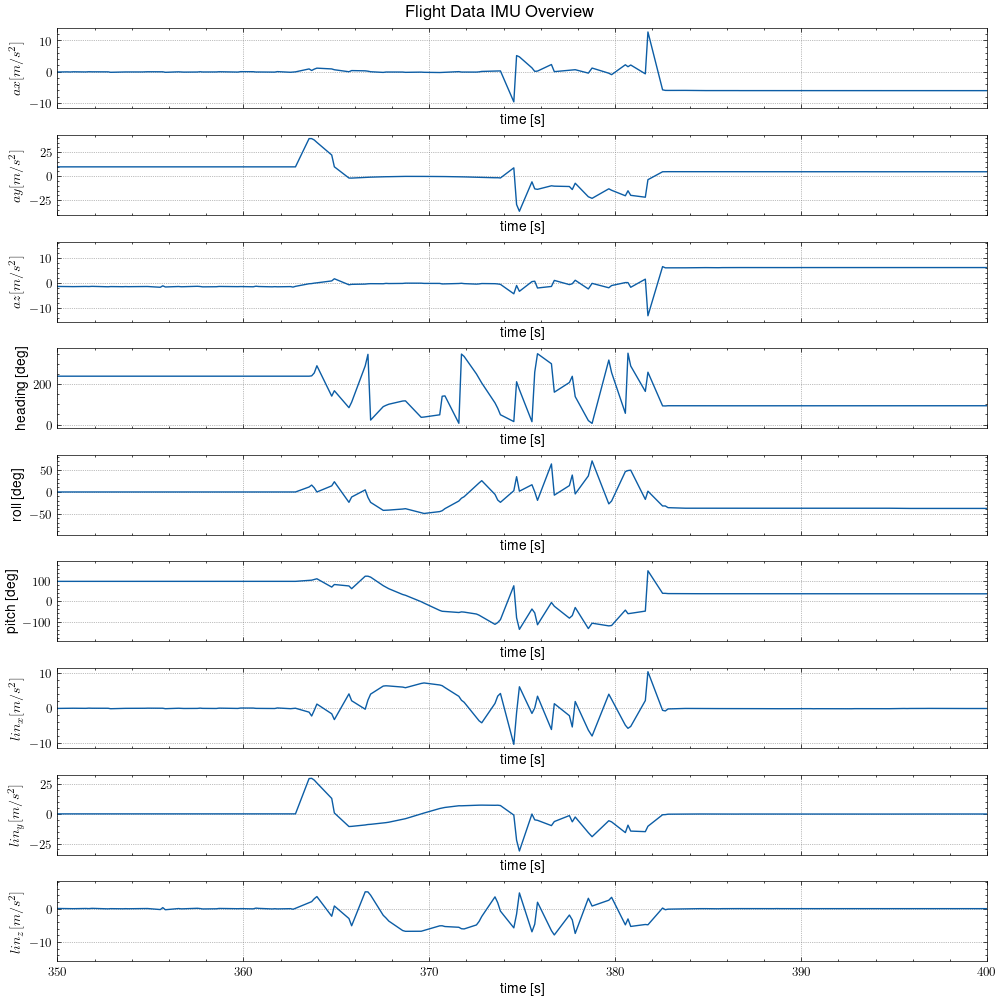

In [8]:
# Plot data on datagrid
import matplotlib.pyplot as plt

fig, axes = plt.subplots(9, 1, layout="compressed", sharex=True, figsize=(10, 10))

fig.suptitle("Flight Data IMU Overview")

for i, x_axis, y_axis, ylabel in zip(
    [0, 1, 2, 3, 4, 5, 6, 7, 8],
    [imu.timestamp_ms/1000, imu.timestamp_ms/1000, imu.timestamp_ms/1000, imu.timestamp_ms/1000, imu.timestamp_ms/1000, imu.timestamp_ms/1000, imu.timestamp_ms/1000, imu.timestamp_ms/1000, imu.timestamp_ms/1000],
    [imu.ax, imu.ay, imu.az, imu.heading, imu.roll, imu.pitch, imu.lin_x, imu.lin_y, imu.lin_z],
    [r"$ax [m/s^2]$", r"$ay [m/s^2]$", r"$az [m/s^2]$", "heading [deg]", "roll [deg]", "pitch [deg]", r"$lin_x [m/s^2]$", r"$lin_y [m/s^2]$", r"$lin_z [m/s^2]$"]):
    axis = axes[i]

    axis.plot(x_axis, y_axis)
    axis.grid(True, linestyle=":", color="gray")
    axis.set_ylabel(ylabel)
    axis.set_xlabel("time [s]")
    axis.set_xlim(350, 400)

plt.show()

Interpolation between 10 m and 30 m elevation
Speed: 5.194259002514752 m/s
Heading: 148.3024397054775 deg


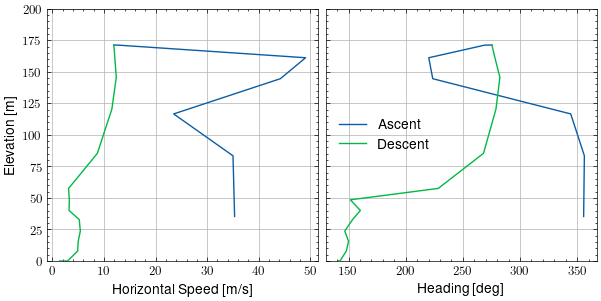

In [9]:
# Estimate wind speed

# assuming horizontal speed is a majority defined by wind speed

t_launch = imu.detect_launch()
launch_mask = (gps.timestamp_ms > t_launch) & (gps.timestamp_ms < t_launch + 20e3)

x, y = gps.get_local_xy(gps.lat[0], gps.lon[0])
x = x[launch_mask]
y = y[launch_mask]
gps_t = gps.timestamp_ms[launch_mask]

dt = np.gradient(gps_t / 1e3)
vx = np.gradient(x) / dt
vy = np.gradient(y) / dt

v = np.sqrt(vx**2 + vy**2) # [m/s]

bearing_to = np.degrees(np.atan2(vx, vy))
wind_from = (bearing_to + 180) % 360 # wind heading

imu_elevation = bar.alt_m
imu_t = bar.timestamp_ms
elevation = np.interp(gps_t.astype(np.float64), imu_t.astype(np.float64), imu_elevation)

i_apogee = np.argmax(elevation)

fig, axes = plt.subplots(1, 2, layout="compressed", sharey=True, figsize=(6, 3))

ax = axes[0]
ax.plot(v[:i_apogee + 1], elevation[:i_apogee + 1], label="Ascent")
ax.plot(v[i_apogee:], elevation[i_apogee:], label="Descent")
ax.set_ylabel("Elevation [m]")
ax.set_xlabel("Horizontal Speed [m/s]")
ax.set_ylim(0, 200)
ax.grid(True)

ax = axes[1]
ax.plot(wind_from[:i_apogee +1], elevation[:i_apogee +1], label="Ascent")
ax.plot(wind_from[i_apogee:], elevation[i_apogee:], label="Descent")
ax.set_xlabel("Heading [deg]")
ax.set_ylim(0, 200)
ax.legend()
ax.grid(True)

plt.savefig("wind-speed-estimation.png")
plt.savefig("wind-speed-estimation.pdf")

h_low = 10
h_high = 30
parachute_descent_mask = (elevation[i_apogee:] > h_low) & (elevation[i_apogee:] < h_high)
print(f"Interpolation between {h_low} m and {h_high} m elevation")
print(f"Speed: {np.mean(v[i_apogee:][parachute_descent_mask])} m/s")
print(f"Heading: {np.mean(wind_from[i_apogee:][parachute_descent_mask])} deg")


plt.show()

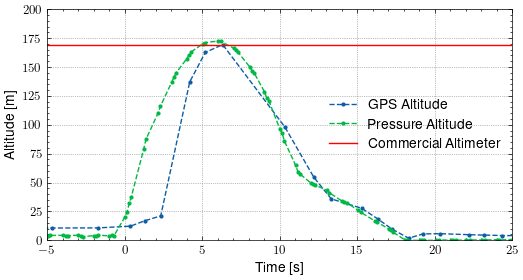

In [10]:
# Plot data on datagrid
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))

mask = ~np.isnan(gps.alt) 
t_launch = imu.detect_launch()

plt.plot((gps.timestamp_ms[mask] - t_launch)/1000, gps.alt[mask], label="GPS Altitude", marker="o", linestyle="--", markersize=2)
plt.plot((bar.timestamp_ms- t_launch)/1000, bar.alt_m, label="Pressure Altitude", marker="o", linestyle="--", markersize=2)
plt.axhline(169.2, label="Commercial Altimeter", color="red")

plt.xlabel("Time [s]")
plt.ylabel("Altitude [m]")
# plt.title("Altitude flight data comparison")
plt.legend()
plt.grid(True, linestyle=":", color="gray")
plt.xlim(-5, 25)
plt.ylim(0, 200)

plt.savefig("altitude-profile.png")
plt.savefig("altitude-profile.pdf")

plt.show()

In [11]:

# TODO: Calculate wind speed and derive other variables

# TODO: Calculate wind direction and plot (Calculate/Estimate from IMU Only)
# TODO.1: Feed wind into trajectory model

# TODO: Plot trajectory from IMU data

2025-11-09 13:46:29.160000+00:00


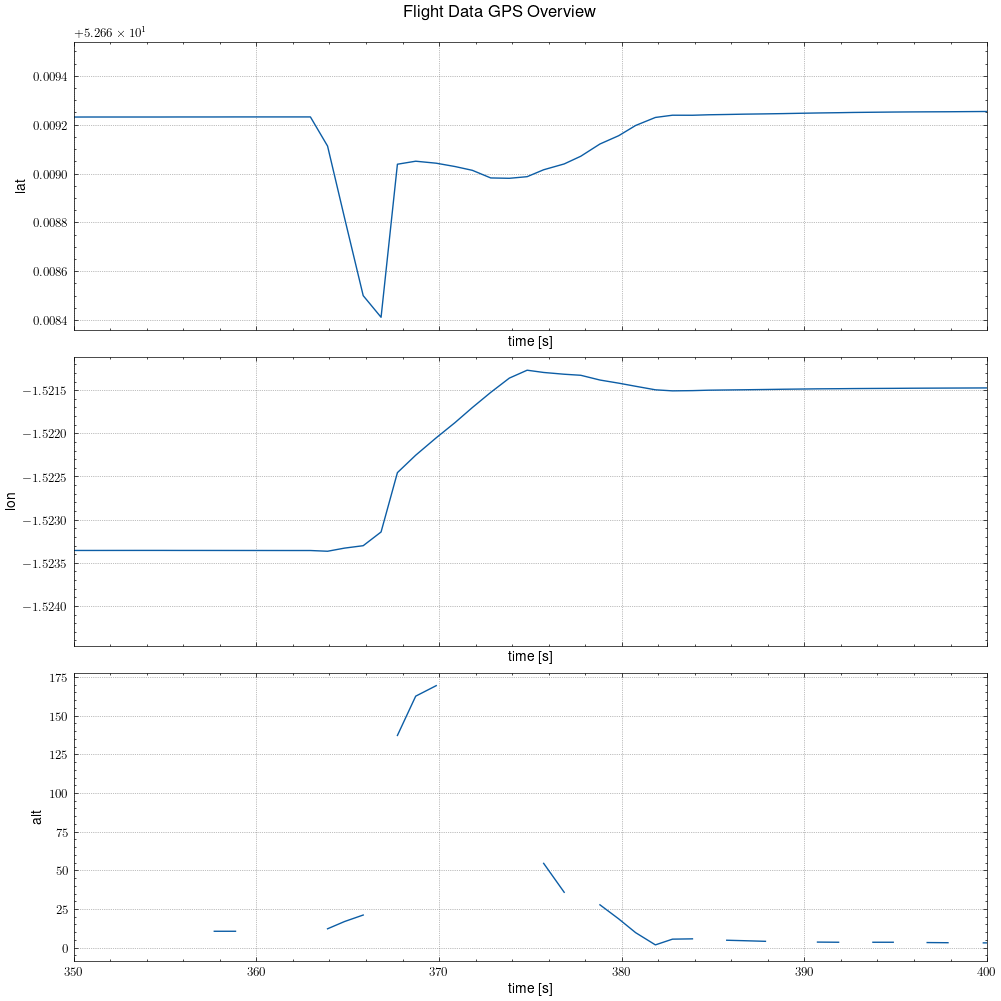

52.66889183333333, -1.5242886666666666
52.668911333333334, -1.5243101666666665
52.66888616666667, -1.5242768333333334
52.66889533333333, -1.5242883333333332
52.66890316666667, -1.5242935
52.668899333333336, -1.5242826666666667
52.668897, -1.5242816666666665
52.668895166666665, -1.52428
52.66889716666667, -1.5242751666666667
52.668895, -1.5242738333333334
52.6688895, -1.5242651666666667
52.6688965, -1.5242635
52.66890516666667, -1.5242583333333335
52.66891283333333, -1.524248
52.668916833333334, -1.5242335
52.668920666666665, -1.5242200000000001
52.668925333333334, -1.5242071666666668
52.668929, -1.5241971666666667
52.66892966666666, -1.5241938333333334
52.668929166666665, -1.524194
52.66892933333333, -1.5241926666666665
52.66893066666667, -1.5241945000000001
52.66893183333333, -1.5241961666666666
52.668933, -1.5241976666666668
52.668933833333334, -1.5241989999999999
52.6689355, -1.5241993333333332
52.668939333333334, -1.5241948333333333
52.66894283333333, -1.5241856666666667
52.6689473

In [12]:
# Plot data on datagrid
import matplotlib.pyplot as plt

print(timestamp_ms_to_datetime(363 * 1000))

fig, axes = plt.subplots(3, 1, layout="compressed", sharex=True, figsize=(10, 10))

fig.suptitle("Flight Data GPS Overview")

for i, x_axis, y_axis, ylabel in zip([0, 1, 2], [gps.timestamp_ms/1000, gps.timestamp_ms/1000, gps.timestamp_ms/1000], [gps.lat, gps.lon, gps.alt], ["lat", "lon", "alt"]):
    axis = axes[i]

    axis.plot(x_axis, y_axis)
    axis.grid(True, linestyle=":", color="gray")
    axis.set_ylabel(ylabel)
    axis.set_xlabel("time [s]")
    axis.set_xlim(350, 400)

plt.show()

for lat, lon in zip(gps.lat, gps.lon):
    print(f"{lat}, {lon}")

0.367 0.0 0.0 4.6303199999999975
1.84 -1.4513870279216416 2.170730070525076 4.74850682885906
2.714 0.7988256485009152 -0.6308104478178521 4.003432499999996
3.854 0.0225021285868334 0.38961821758373866 4.148968235294117
4.691 -0.3262808352186911 1.2616208956357042 4.528761379310343
5.766 0.40503829596449126 0.8348961812145591 3.943222040816323
6.781 0.47254469125174753 0.5751507025617426 3.906383999999996
7.798 0.5850553442834782 0.37106496916503545 3.909874545454542
8.843 0.911336188513966 0.5937039509804458 4.612885445026175
9.8 1.001344725783477 0.3525117207463323 4.025788531468523
10.856 1.5864001710355162 -0.2597454786528166 4.693449648894662
11.824 1.698910685386404 0.5194909573056332 4.08079006802721
12.73 2.0476934707004553 1.4842598774511144 4.618956551724138
13.88 2.745259137484353 2.3377093062934042 4.201602352941174
14.856 3.7241013644184133 2.782987269924225 4.817491999999995
15.801 4.635437144526313 3.2097119843453696 4.09725684210526
16.708 5.501768550086135 3.72920294165

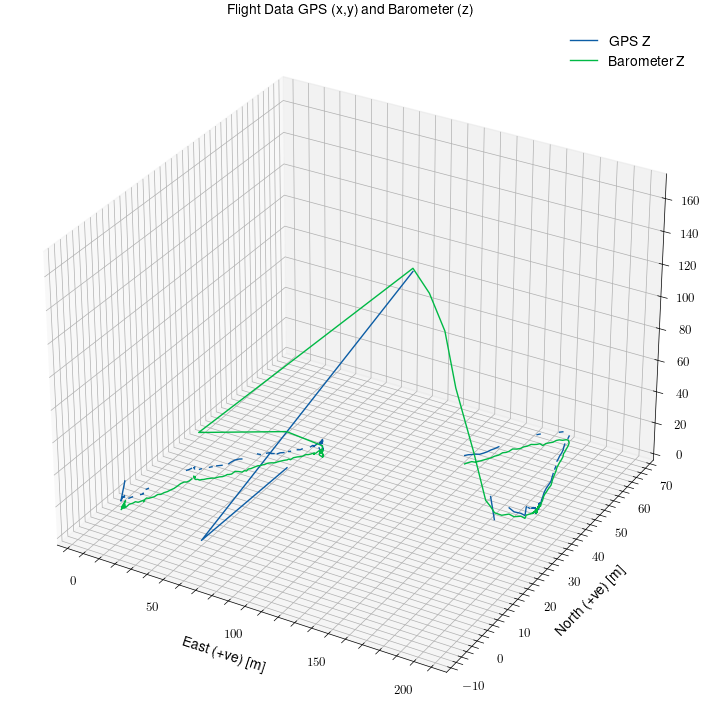

In [13]:
# %matplotlib widget

# Plot data on datagrid
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

plt.title("Flight Data GPS (x,y) and Barometer (z)")

x, y = gps.get_local_xy(gps.lat[0], gps.lon[0])

gps_t = np.asarray(gps.timestamp_ms, dtype=np.float64) / 1000.0
bar_t = np.asarray(bar.timestamp_ms, dtype=np.float64) / 1000.0

mask = (gps_t < 365) | (gps_t > 369)
gps_t = gps_t[mask]
x = x[mask]
y = y[mask]
z_gps = gps.alt[mask]

z = np.asarray(bar.alt_m, dtype=np.float64)

z_at_gps_t = np.interp(gps_t, bar_t, z)

# z = bar.alt_m
# bar_t = bar.timestamp_ms
# z_at_gps_t = np.interp(gps_t, bar_t, z)

for t1, x1, y1, z1 in zip(gps_t, x, y, z_at_gps_t):
    print(t1, x1, y1, z1)

ax.plot(x, y, z_gps, label="GPS Z")
ax.plot(x, y, z_at_gps_t, label="Barometer Z")
ax.legend()

ax.set_zlabel("Up [m]")
ax.set_xlabel("East (+ve) [m]")
ax.set_ylabel("North (+ve) [m]")

plt.show()